In [65]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import PowerTransformer,FunctionTransformer

In [66]:
df=sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [67]:
df.shape

(53940, 10)

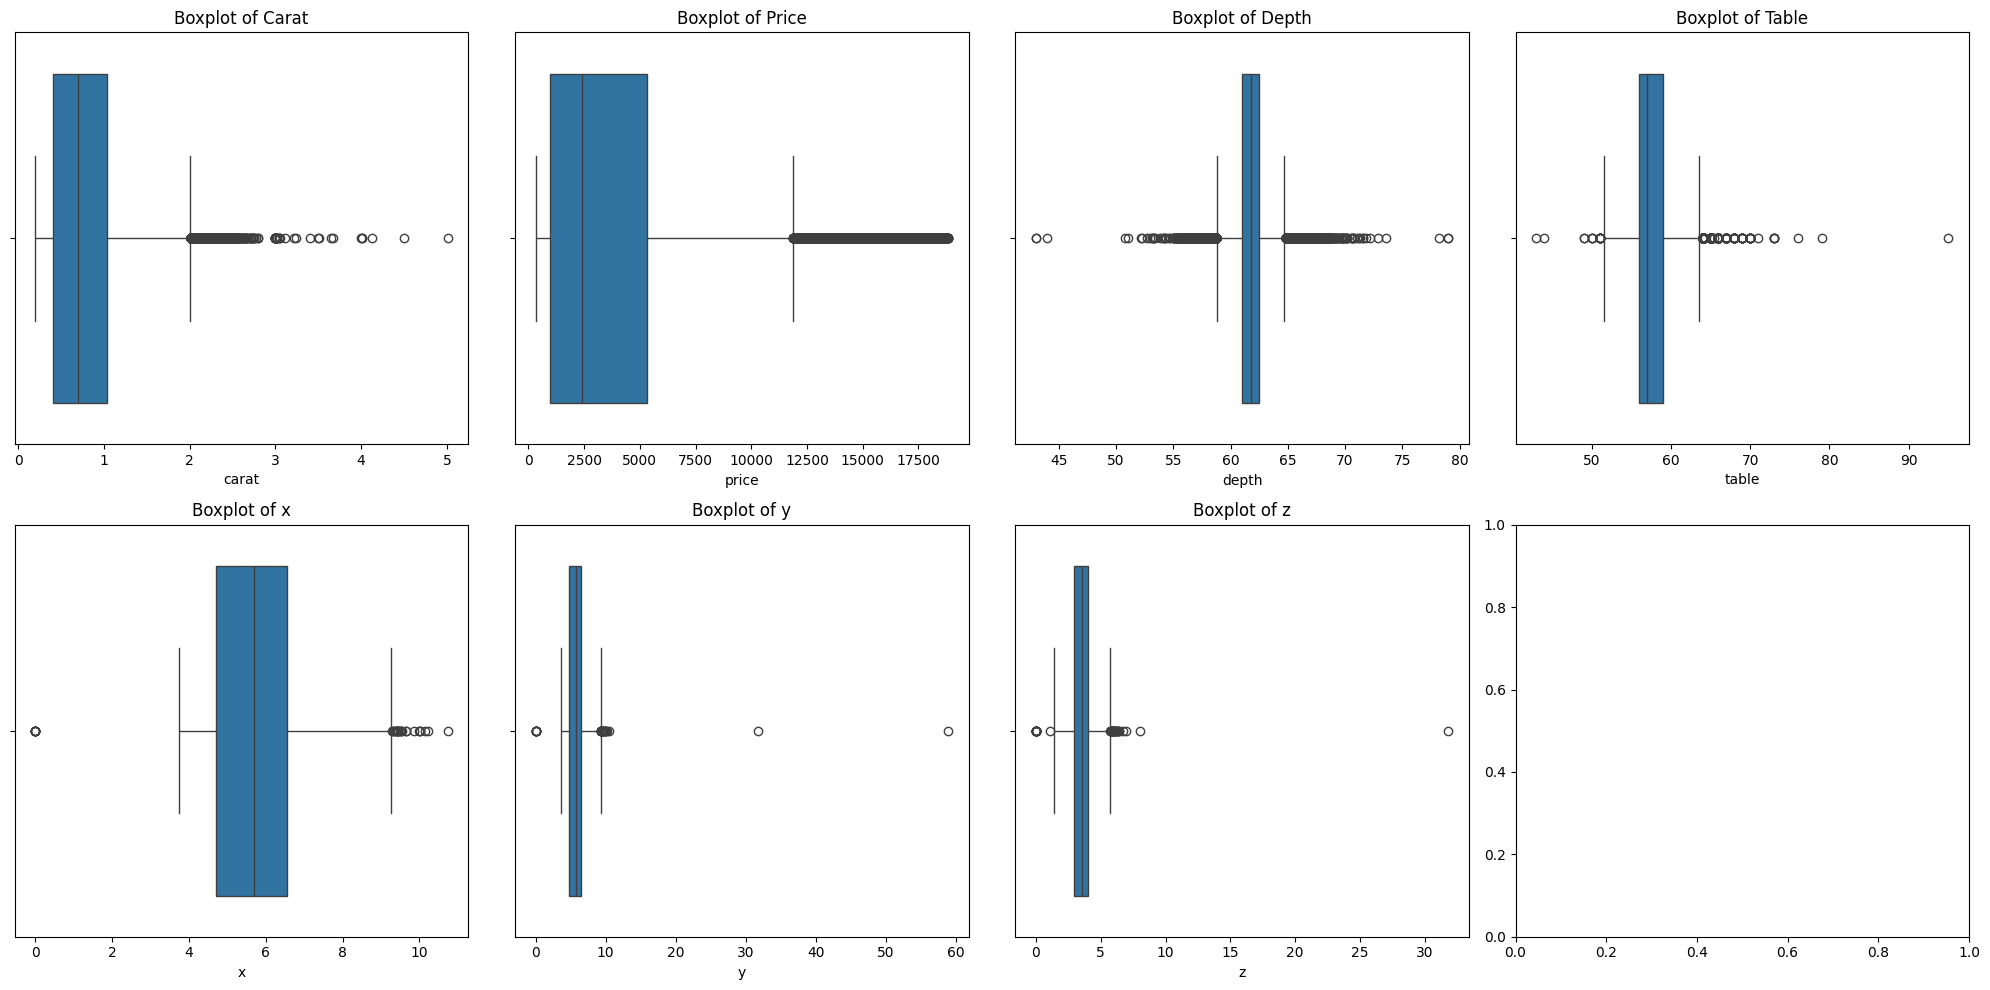

In [68]:
#outliers before the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [69]:
#conditon to remove
df=df[(df['x']>0)&(df['y']>0)&(df['z']>0)]

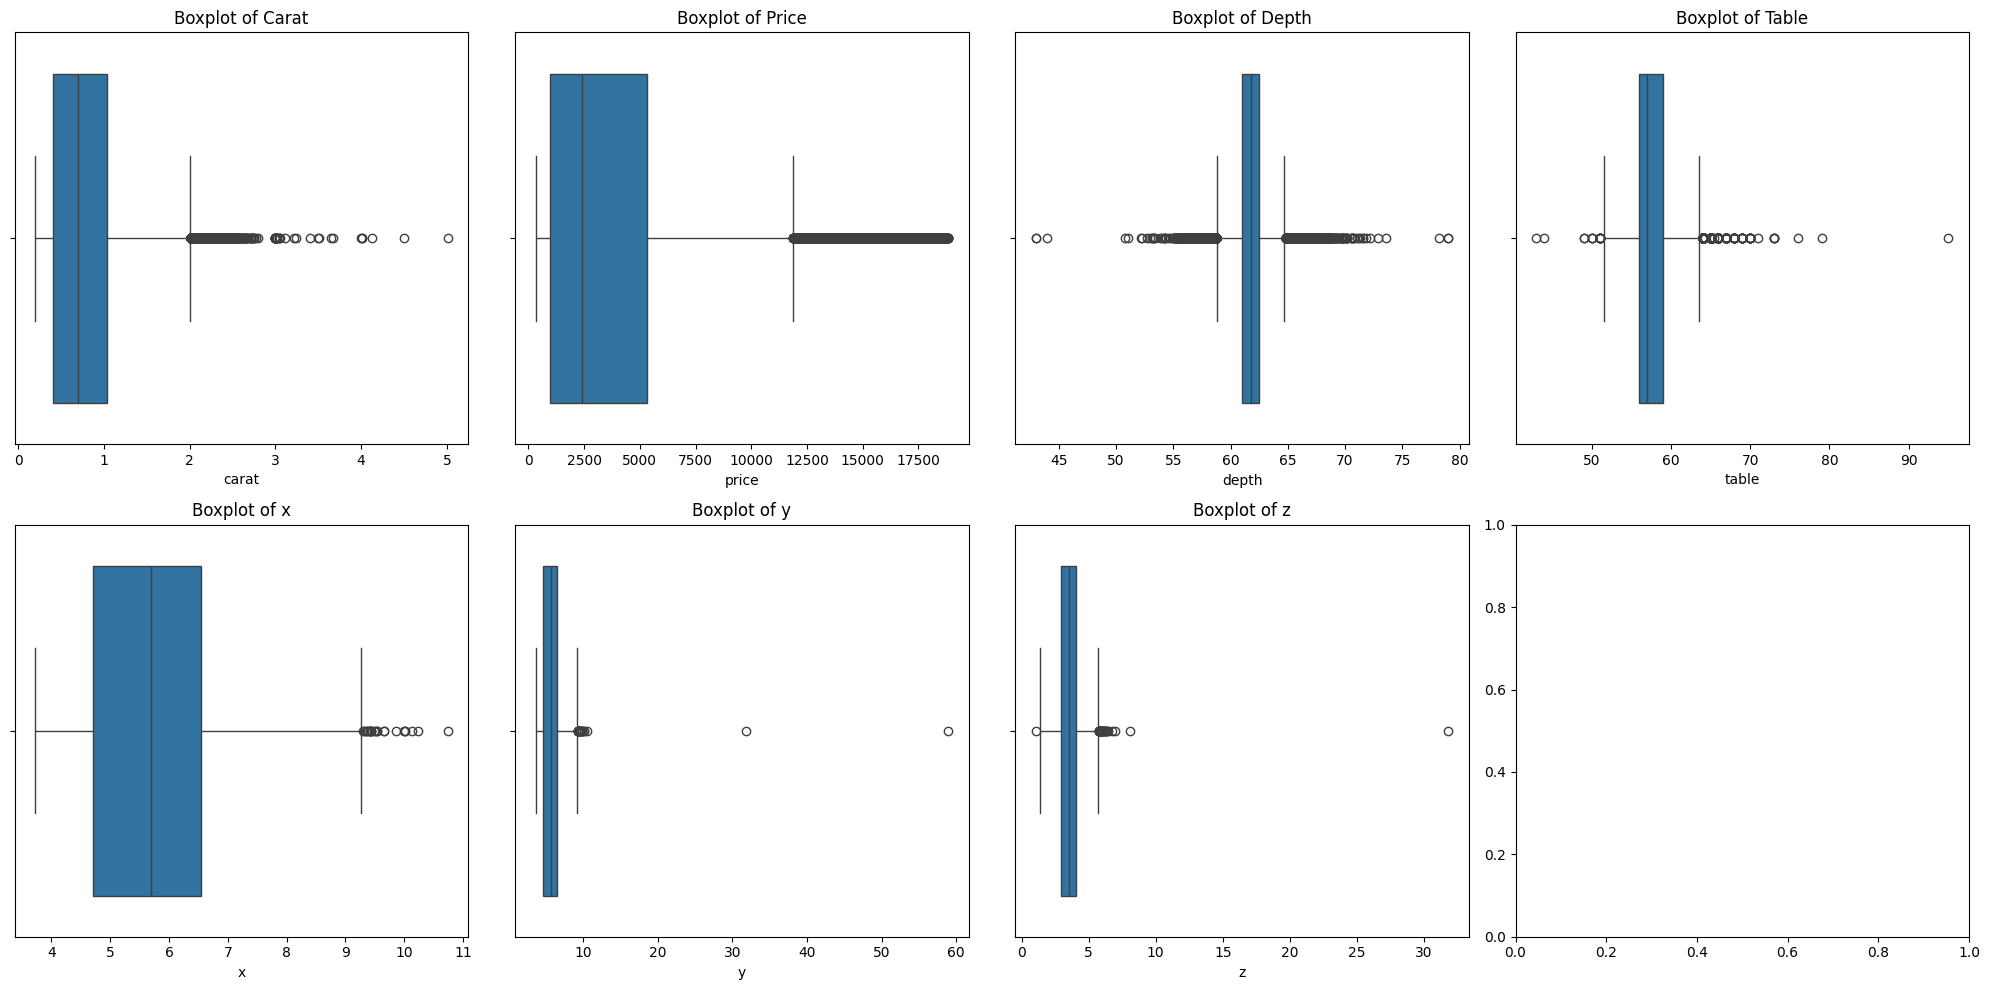

In [70]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [71]:
df.shape

(53920, 10)

In [72]:
# 3. Ab Statistical Outliers ko hatayein (IQR Method)
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condition banao
    condition = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    
    # 'df' ko filter karo (Yeh sabse important hai)
    df = df[condition]

print(f"Size after removing statistical outliers: {df.shape}")



Size after removing statistical outliers: (46530, 10)


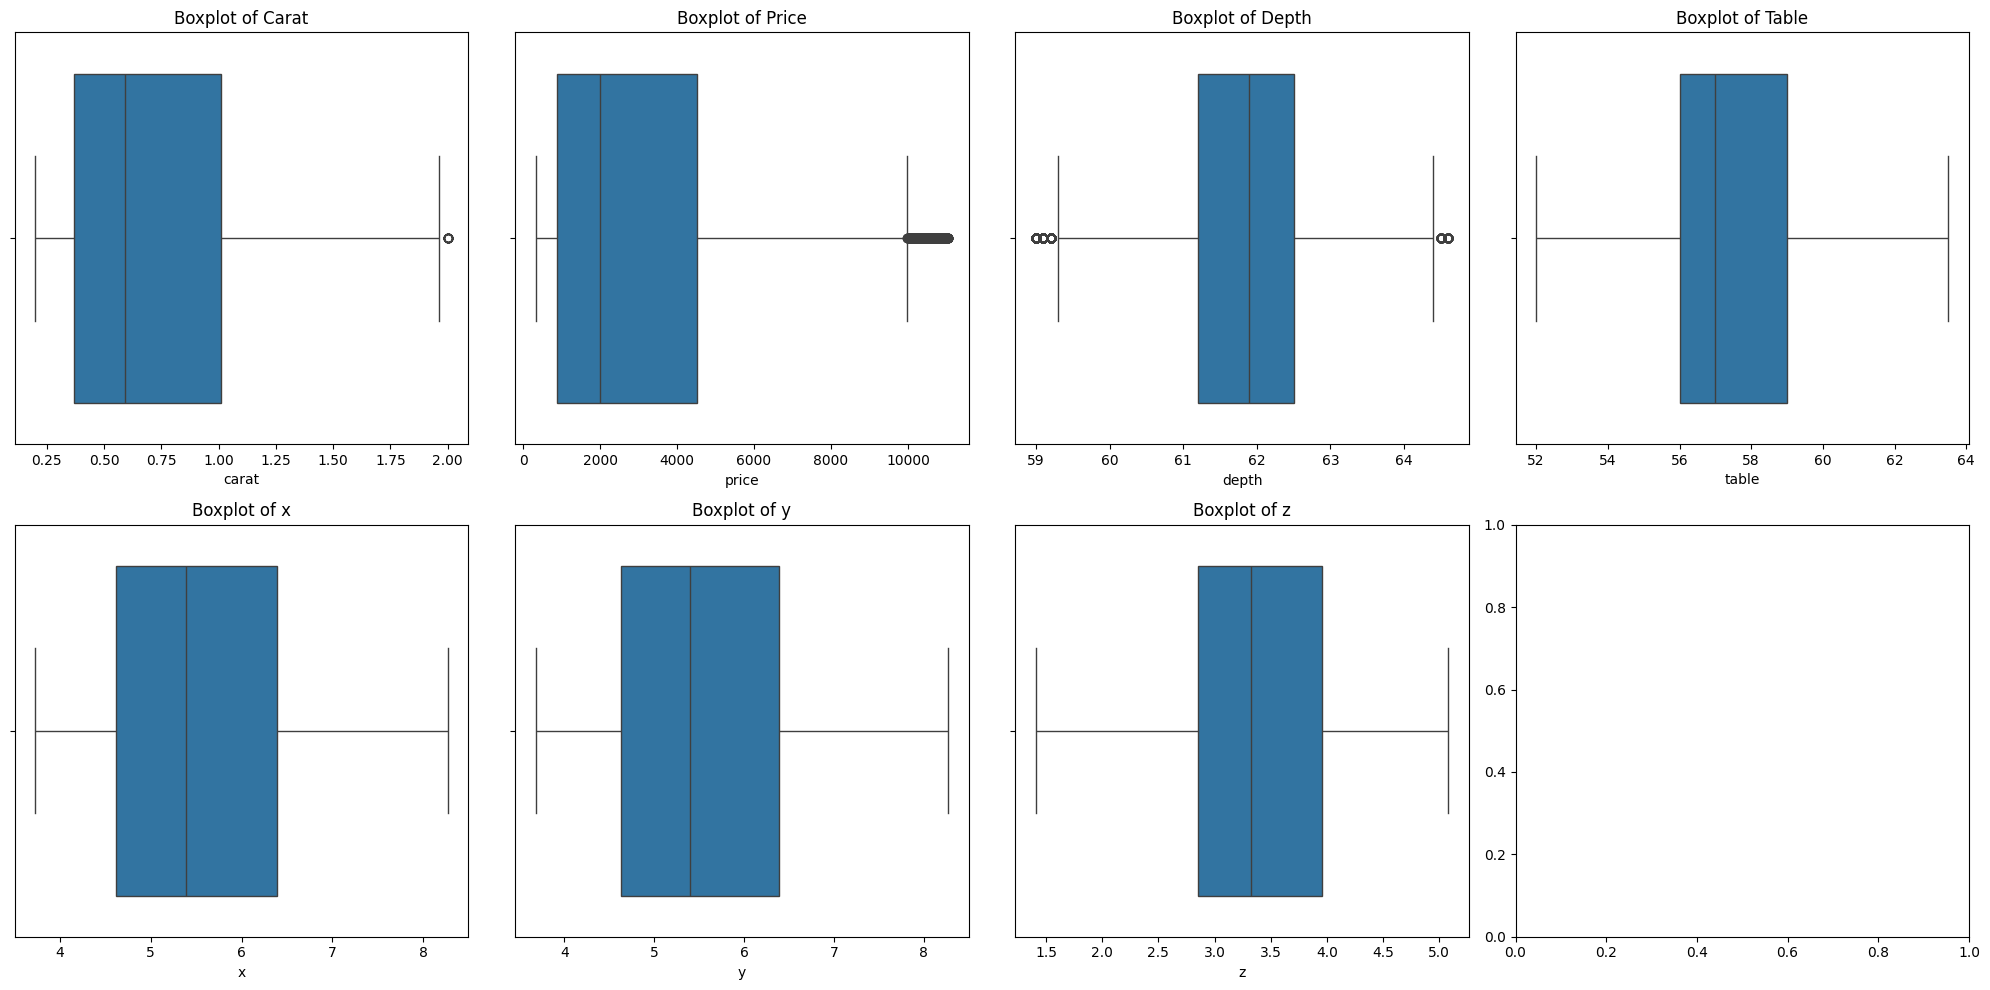

In [73]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [74]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [75]:
df[['cut', 'color', 'clarity']] = df[['cut', 'color', 'clarity']].apply(LabelEncoder().fit_transform)

In [76]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,6,7,62.8,57.0,336,3.94,3.96,2.48


In [ ]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.histplot(data=df['carat'],kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Histplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.histplot(data=df['price'],kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Histplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.histplot(data=df['depth'],kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Histplot of Depth')

# --- Fill the rest of the plots ---
sns.histplot(data=df['table'],kde=True, ax=axs[0, 3])
axs[0, 3].set_title('Histplot of Table')

sns.histplot(data=df['x'], kde=True,ax=axs[1, 0])
axs[1, 0].set_title('Histplot of x')

sns.histplot(data=df['y'], kde=True,ax=axs[1, 1])
axs[1, 1].set_title('Histplot of y')

sns.histplot(data=df['z'], kde=True,ax=axs[1, 2])
axs[1, 2].set_title('Histplot of z')



plt.tight_layout()
plt.show()


In [ ]:
ptf= PowerTransformer(method='yeo-johnson')

In [ ]:
df['price_tranform']= ptf.fit_transform(df[['price']])

<Axes: xlabel='price_tranform', ylabel='Count'>

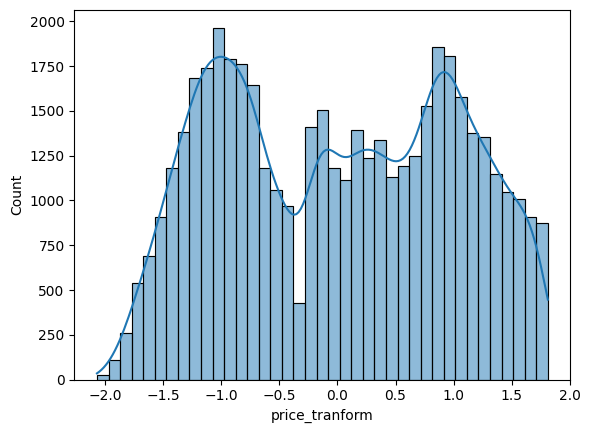

In [ ]:
sns.histplot(data=df['price_tranform'],kde=True)

In [ ]:
X = df.drop(columns=['cut'])
y = df['cut']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(37224, 10)

In [ ]:
X_train.head()

,carat,color,clarity,depth,table,price,x,y,z,price_tranform
11705,0.34,1,2,59.3,58.0,596,4.55,4.59,2.71,6.391917
52900,0.73,3,5,62.5,56.0,2586,5.78,5.74,3.60,7.858254
14596,1.24,5,5,60.1,59.0,5889,7.02,6.95,4.20,8.681011
7064,0.33,3,5,59.3,61.0,579,4.49,4.51,2.67,6.363028
47336,0.23,1,6,61.4,59.0,530,3.93,3.99,2.43,6.274762


<Axes: xlabel='carat', ylabel='Count'>

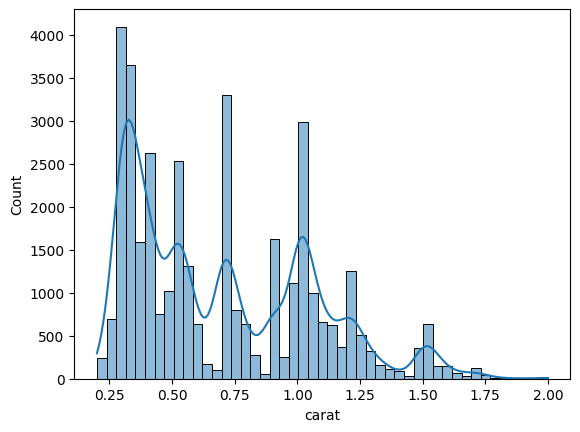

In [ ]:
sns.histplot(data=X_train['carat'],kde=True)

In [ ]:
X_train.head()

,carat,color,clarity,depth,table,price,x,y,z,price_tranform
11705,0.34,1,2,59.3,58.0,596,4.55,4.59,2.71,6.391917
52900,0.73,3,5,62.5,56.0,2586,5.78,5.74,3.60,7.858254
14596,1.24,5,5,60.1,59.0,5889,7.02,6.95,4.20,8.681011
7064,0.33,3,5,59.3,61.0,579,4.49,4.51,2.67,6.363028
47336,0.23,1,6,61.4,59.0,530,3.93,3.99,2.43,6.274762


In [ ]:
for col in X_train:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train =X_train[(X_train[col] >= lower) & (X_train[col] <= upper)]


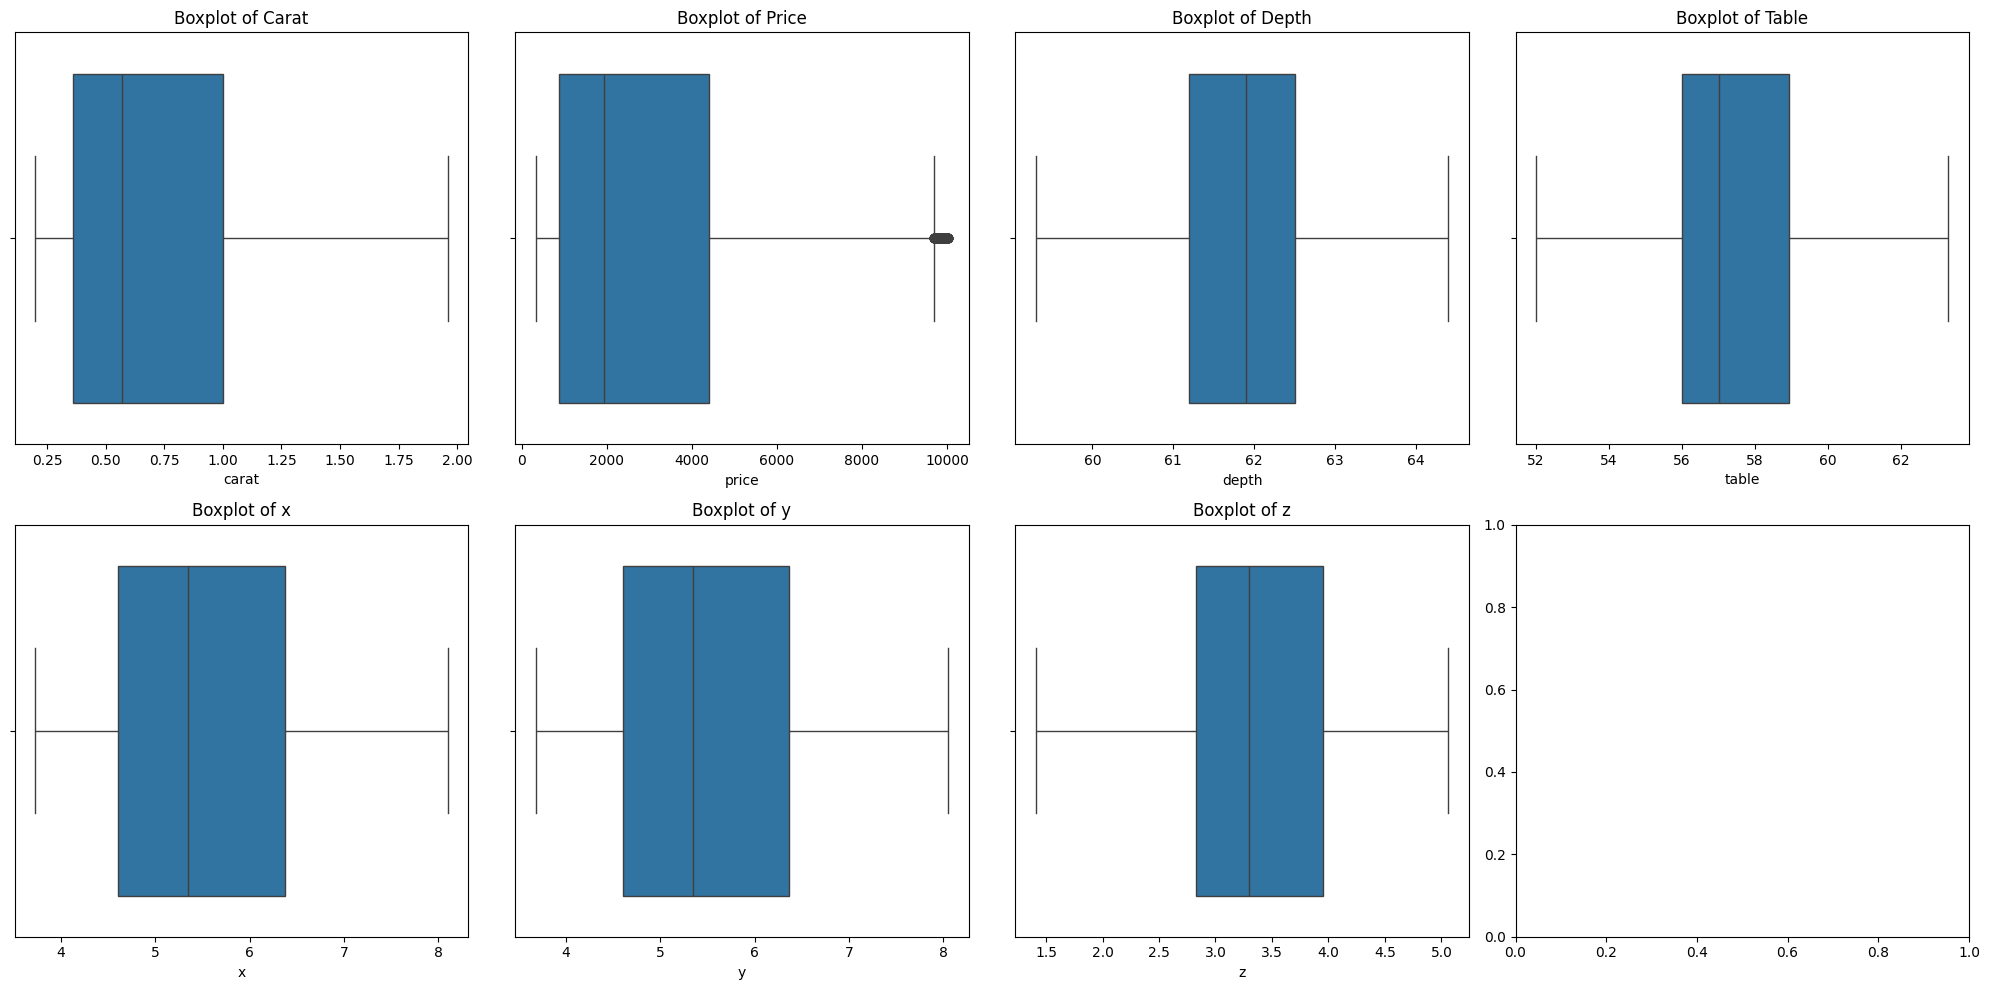

In [ ]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=X_train['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=X_train['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=X_train['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=X_train['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=X_train['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=X_train['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=X_train['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[-0.98097747, -0.90571398, -1.09326065, ..., -0.96002773,
        -1.16710624, -1.33419044],
       [ 0.1331176 ,  0.28014478,  0.64423511, ...,  0.26482112,
         0.35205185,  0.30752514],
       [ 1.59001114,  1.46600353,  0.64423511, ...,  1.55357514,
         1.37620337,  1.22868656],
       ...,
       [-0.43821321, -0.3127846 ,  0.06506986, ..., -0.28902358,
        -0.31364664, -0.20895403],
       [ 0.33308338, -0.3127846 , -1.09326065, ...,  0.4032823 ,
         0.47153619,  0.43191703],
       [ 1.50431152, -0.90571398, -1.09326065, ...,  1.3512088 ,
         1.39327256,  1.40393218]], shape=(35932, 10))

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

ValueError: Found input variables with inconsistent numbers of samples: [35932, 37224]

In [ ]:
X_train.shape

(43152, 9)

In [ ]:
y_pred =knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.6654616240266963

In [ ]:
# Example new diamond
new_diamond = [[0.25, 60, 58, 330, 4.0, 4.1, 2.5]]
new_diamond_scaled = scaler.transform(new_diamond)

prediction = knn.predict(new_diamond_scaled)
prediction


d:\Programing\Machine learning\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 7 features, but StandardScaler is expecting 9 features as input.

In [ ]:
decoded_prediction = [
    encoders[col].inverse_transform([prediction[0][i]])[0]
    for i, col in enumerate(y.columns)
]

print("Predicted values (cut, color, clarity):", decoded_prediction)


Predicted values (cut, color, clarity): [np.int64(4), np.int64(1), np.int64(4)]


In [ ]:
for cols in ['color','clarity']:
    le=LabelEncoder()
    dia[cols]=le.fit_transform(dia[cols])

np.random.seed(43)
ran=np.random.choice(dia.index, size=int(0.91*len(dia)), replace=False)
print(dia.info())

scaler=MinMaxScaler()
columns_for_norm=['depth','table','price','x','y','z']
dia_norm=pd.DataFrame(scaler.fit_transform(dia[columns_for_norm]), columns=columns_for_norm)


#Original Data Summ
print("\nOriginal Data Summ\n")
print(dia.describe())
print("\nNormalised Data Summ\n")
print(dia_norm.describe())


#columns_for_training=['depth','x','y','z']
dia_train=dia_norm.loc[ran,:]
dia_test=dia_norm.drop(ran)
dia_target_cat=dia.iloc[ran, 1]
dia_test_cat=dia.drop(ran)['cut']

#KNN
knn=KNeighborsClassifier(n_neighbors=32,metric='manhattan')
knn.fit(dia_train, dia_target_cat)
pr=knn.predict(dia_test)

#Confusion Matrix
matrix1=confusion_matrix(dia_test_cat, pr)
print("\nConfusion Matrix\n",matrix1)


#Accuracy Score
ac1=accuracy_score(dia_test_cat, pr)*100
print("\nAccuracy: {:.2f}".format(ac1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     4